# Palace Flip-Chip Simulation of a Flipmon Qubit

This notebook demonstrates a two-chip (flip-chip) FEM simulation of a
**flipmon**: a circular transmon whose shunt capacitor is a vacuum-gap
parallel-plate capacitor formed by flipping a second chip on top of the
qubit chip {cite:p}`liVacuumgapTransmonQubits2021`. It extends the
{doc}`palace_eigenmode_qubit_resonator` notebook from a single chip to a
two-chip stack: two metal levels, two silicon substrates, and conducting
indium bumps bridging the inter-chip gap, all driven through
[gsim](https://gdsfactory.github.io/gsim/) and solved with
[Palace](https://awslabs.github.io/palace/).

The flipmon topology, as drawn by {func}`~qpdk.cells.flipmon_with_bbox`:

- The **bottom chip** (metal level M1) carries the inner circular pad, the
  outer ring, and the Josephson junction between them.
- The **top chip** (metal level M2, flipped so its metal faces down) carries
  the top circle, galvanically connected to the inner pad through a central
  indium bump.
- The qubit island is the inner pad + top circle node, and the shunt
  capacitance is the vacuum gap between the top circle and the outer ring,
  the junction's counter-electrode.

The workflow, with the mesh itself treated as something to verify rather
than trust:

````{only} html
```{mermaid}
flowchart TB
    A["Flip-chip layout<br>(qpdk cells)"]
    B["FEM regions<br>(two metal levels + bumps)"]
    C["Two-chip layer stack"]
    D["Analytical estimate<br>(vacuum-gap capacitor)"]
    E["Mesh"]
    F["Verify the mesh<br>(volumes, element sizes, port connectivity)"]
    G["Eigenmode solve"]
    H["Identify the qubit mode<br>(participation, L scaling, bump A/B)"]
    A --> B --> C --> E --> F --> G --> H
    D --> H
```
````

The flip-chip geometry is not just packaging: with a roughly 10 µm
inter-chip gap, a large fraction of the qubit's electric field energy can
reside in the vacuum gap instead of lossy dielectric interfaces, and the
metal-air interface participation grows to dominate decoherence
{cite:p}`liVacuumgapTransmonQubits2021`. The FEM resolves the field in every
layer of the stack, including the gap and the bumps.

::::{admonition} Required extras
:class: tip

This notebook needs the `models` extra:

```bash
uv add "qpdk[models]"
# or, from a checkout of this repository:
uv sync --extra models
# or with pip:
pip install "qpdk[models]"
```

The simulation cells additionally need the [Palace](https://awslabs.github.io/palace/)
solver itself, which is external to qpdk; the cells that invoke it are fenced,
and the Palace results are embedded below so the analysis runs anywhere.

See the {ref}`extras reference <notebook-extras>` for what each extra installs.
::::

The results shown below were produced with Palace on an HPC cluster; the
solver data is embedded in hidden cells so the rendered docs show the
analysis, not the raw tables.

In [1]:
import sys
from pathlib import Path

if "google.colab" in sys.modules:
    import subprocess

    print("Running in Google Colab. Installing QPDK...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "qpdk[models] @ git+https://github.com/gdsfactory/quantum-rf-pdk.git",
    ])

In [2]:
import gdsfactory as gf
import klayout.db as kdb
import matplotlib.pyplot as plt
import matplotlib_inline
import numpy as np
from matplotlib.colors import LogNorm
from scipy.ndimage import gaussian_filter

from qpdk import PDK, logger
from qpdk.cells import flipmon_with_bbox
from qpdk.models.constants import ε_0
from qpdk.simulation import FLIP_CHIP_FEM_LAYERS, to_flip_chip_regions
from qpdk.tech import LAYER

PDK.activate()

for style in (Path("docs/qpdk.mplstyle"), Path("../docs/qpdk.mplstyle"), "qpdk"):
    try:
        plt.style.use(style)
        break
    except OSError:
        continue
matplotlib_inline.backend_inline.set_matplotlib_formats("png")

## Simulation layout

The device under test is the {func}`~qpdk.cells.flipmon_with_bbox` cell: the
flipmon inside its etched bounding circles. The cell draws both metal levels
subtractively: each level's etched bounding circle removes everything inside
it except the drawn pads, so the surrounding ground plane and the isolated
pads come out of the same mask.

Two additions make the standalone layout a well-posed simulation, and the
wrapper below adds both:

- **Corner ground bumps.** The two chips carry separate ground planes that
  would otherwise float relative to each other. Four indium bumps near the
  simulation-area corners tie them into a single ground node, exactly as a
  real flip-chip assembly grounds the top chip.
- **Junction lead tabs.** The lumped junction port must span the 20 µm gap
  between the inner circle and the outer ring as a rectangle. Both facing
  edges are circular arcs, so a rectangle clipped by them is no longer
  rectangular, and Palace rejects non-rectangular lumped port surfaces. Two
  small M1 lead tabs straighten the facing edges, narrowing the local lead
  gap to 12 µm the way real junction leads approach each other. The port
  rectangle must then exactly abut the tab edges: a port rectangle that
  overhangs the thin tabs makes the meshing pipeline's boolean cuts delete
  them, which leaves the port electrically orphaned (verified below).

A ``SIM_AREA`` rectangle around the device bounds the simulation domain on
both chips.

In [3]:
BUMP_RADIUS = 7.5  # µm, matches the cell's own indium bump


def _bump(x: float, y: float) -> kdb.DPolygon:
    """Return a circular bump polygon of the standard radius at (x, y)."""
    return kdb.DPolygon.ellipse(
        kdb.DBox(x - BUMP_RADIUS, y - BUMP_RADIUS, x + BUMP_RADIUS, y + BUMP_RADIUS), 64
    )


@gf.cell
def sim_component() -> gf.Component:
    """Flipmon with corner ground bumps, lead tabs and a simulation area."""
    c = gf.Component()
    ref = c << flipmon_with_bbox()
    c.add_ports(ref.ports)
    # Tie the two chips' ground planes into a single ground node.
    for x, y in ((-150, -150), (150, -150), (-150, 150), (150, 150)):
        c.kdb_cell.shapes(LAYER.IND).insert(_bump(x, y))
    # Junction lead tabs: straight metal edges across the junction gap so the
    # lumped port spans a rectangular lead gap instead of curved circle arcs.
    half_width = ref.ports["junction"].width / 2
    c.kdb_cell.shapes(LAYER.M1_DRAW).insert(
        kdb.DBox(52.0, -half_width, 60.0, half_width)
    )
    c.kdb_cell.shapes(LAYER.M1_DRAW).insert(
        kdb.DBox(72.0, -half_width, 80.0, half_width)
    )
    c.kdb_cell.shapes(LAYER.SIM_AREA).insert(c.bbox().enlarged(100, 100))
    return c


layout_c = sim_component()
logger.info(f"simulation area: {layout_c.bbox()}")
for port in layout_c.ports:
    logger.info(
        f"port {port.name}: ({port.center[0]:.1f}, {port.center[1]:.1f}) µm,"
        f" orientation {port.orientation:.0f}°"
    )

2026-09-26 17:55:15.528 | INFO     | __main__:<module>:34 - simulation area: (-270,-270;270,270)


2026-09-26 17:55:15.528 | INFO     | __main__:<module>:36 - port center: (0.0, 0.0) µm, orientation 0°


2026-09-26 17:55:15.528 | INFO     | __main__:<module>:36 - port inner_ring_near_junction: (30.0, 0.0) µm, orientation 0°


2026-09-26 17:55:15.528 | INFO     | __main__:<module>:36 - port outer_ring_near_junction: (80.0, 0.0) µm, orientation 180°


2026-09-26 17:55:15.528 | INFO     | __main__:<module>:36 - port outer_ring_outside: (140.0, 0.0) µm, orientation 0°


2026-09-26 17:55:15.529 | INFO     | __main__:<module>:36 - port junction: (67.4, 0.0) µm, orientation 90°


## From etch layers to flip-chip regions

{func}`~qpdk.simulation.to_flip_chip_regions` applies the subtractive
convention on both metal levels (conductor is ``SIM_AREA - ETCH + DRAW``,
matching the flip-chip layer stack) and copies the indium bump layer to its
own region. The result carries six regions: two silicon substrates, the two
zero-thickness metal sheets, the vacuum gap, and the bumps.

In [4]:
regions = to_flip_chip_regions(layout_c)
rlayout = regions.kdb_cell.layout()
for name, (lnum, ldt) in FLIP_CHIP_FEM_LAYERS.items():
    region = kdb.Region(regions.kdb_cell.begin_shapes_rec(rlayout.layer(lnum, ldt)))
    logger.info(
        f"{name:>14} ({lnum},{ldt}): {len(region.merged())} polygons,"
        f" {region.area() / 1e6:.0f} µm²"
    )

2026-09-26 17:55:15.535 | INFO     | __main__:<module>:5 -      SUBSTRATE (102,0): 1 polygons, 291600 µm²


2026-09-26 17:55:15.535 | INFO     | __main__:<module>:5 -             M1 (103,0): 3 polygons, 253965 µm²


2026-09-26 17:55:15.535 | INFO     | __main__:<module>:5 -         VACUUM (104,0): 1 polygons, 291600 µm²


2026-09-26 17:55:15.536 | INFO     | __main__:<module>:5 -           BUMP (105,0): 5 polygons, 882 µm²


2026-09-26 17:55:15.536 | INFO     | __main__:<module>:5 -             M2 (106,0): 2 polygons, 258938 µm²


2026-09-26 17:55:15.536 | INFO     | __main__:<module>:5 -  SUBSTRATE_TOP (107,0): 1 polygons, 291600 µm²


The region counts are the circuit topology made visible: M1 splits into the
ground plane, the isolated outer ring and the isolated inner circle, M2 into
the top ground plane and the isolated top circle, and the five bumps each
overlap conductor on both chips, so they connect what they must connect.
The one at the center joins the inner circle to the top circle (the qubit
island); the four at the corners join the ground planes.

In [5]:
m1 = kdb.Region(
    regions.kdb_cell.begin_shapes_rec(rlayout.layer(*FLIP_CHIP_FEM_LAYERS["M1"]))
).merged()
m2 = kdb.Region(
    regions.kdb_cell.begin_shapes_rec(rlayout.layer(*FLIP_CHIP_FEM_LAYERS["M2"]))
).merged()
bumps = kdb.Region(
    regions.kdb_cell.begin_shapes_rec(rlayout.layer(*FLIP_CHIP_FEM_LAYERS["BUMP"]))
).merged()
assert (bumps - m1).is_empty(), "a bump does not land on the bottom-chip metal"
assert (bumps - m2).is_empty(), "a bump does not land on the top-chip metal"

The same subtractive-to-positive conversion as the single-chip case, applied
once per metal level; see {ref}`subtractive-to-positive` for the rule and
{doc}`palace_eigenmode_qubit_resonator` for the walkthrough.

## Analytical qubit estimate

Before meshing anything, the vacuum-gap capacitor gives a first estimate of
the qubit frequency. Treating the top circle and the outer ring as parallel
plates across the inter-chip gap $g$, the overlapping area is the
annulus between the ring's inner edge (radius 80 µm) and the top circle's
edge (radius 110 µm):

```{math}
C_{\mathrm{vac}} = \frac{\varepsilon_0 \pi (r_{\mathrm{top}}^2 - r_{\mathrm{ring,in}}^2)}{g}
```

The qubit island also sees fringing fields at the plate edges, the substrate
beneath both chips, and the small M1-level capacitance across the junction
gap, so $C_\Sigma > C_{\mathrm{vac}}$ and the parallel-plate value
bounds the qubit frequency from above. Deep in the transmon regime the
linearized mode sits at
$f_q \approx 1 / (2\pi\sqrt{L_J C_\Sigma})$
{cite:p}`kochChargeinsensitiveQubitDesign2007a,krantzQuantumEngineersGuide2019`.

In [6]:
BUMP_THICKNESS = 10.0  # µm, inter-chip gap
TOP_CIRCLE_RADIUS = 110.0  # µm
RING_INNER_RADIUS = 80.0  # µm
L_J = 10e-9  # H, linearized junction inductance

c_vac = (
    ε_0
    * np.pi
    * (TOP_CIRCLE_RADIUS**2 - RING_INNER_RADIUS**2)
    * 1e-12
    / (BUMP_THICKNESS * 1e-6)
)
f_q_upper = 1 / (2 * np.pi * np.sqrt(L_J * c_vac))
logger.info(f"parallel-plate vacuum capacitance: {c_vac * 1e15:.2f} fF")
logger.info(f"qubit frequency upper bound: {f_q_upper / 1e9:.2f} GHz")

2026-09-26 17:55:15.541 | INFO     | __main__:<module>:14 - parallel-plate vacuum capacitance: 15.86 fF


2026-09-26 17:55:15.542 | INFO     | __main__:<module>:15 - qubit frequency upper bound: 12.64 GHz


## Simulation setup with gsim

gsim turns the converted layout into a 3-D model: `flip_chip_stack` assigns
each region a material and a z-extent, and the simulation classes configure
the ports. gsim is part of the `models` extra, so the setup below runs as-is;
only the Palace solver itself stays external. The same geometry and stack
feed both solves below.

Two 500 µm silicon chips face each other across the 10 µm bump gap, matching
the qpdk flip-chip layer stack: M1 at z=0, M2 at z=10 µm, the bottom
substrate below and the top substrate (flipped) above. Both substrates use
the qpdk microwave silicon ($\varepsilon_r = 11.45$,
$\tan\delta = 2.7 \times 10^{-6}$
{cite:p}`checchinMeasurementLowTemperatureLoss2022`) and both metals become PEC
sheets. The bumps are "via" layers whose z-range is written to abut the two
conductor sheets exactly (z = 0 to the 10 µm gap height); their material
needs an explicit indium entry with a conductivity, without which gsim
demotes each via to a 2-D PEC sheet at its base and the two chips no
longer connect.

The junction port points radially across the lead gap; `resistance=0.0`
keeps the linearized junction purely reactive.

In [7]:
from qpdk.simulation import flip_chip_stack

stack = flip_chip_stack(substrate_thickness=500.0, bump_thickness=BUMP_THICKNESS)
regions.ports["junction"].orientation = 0.0
# Center the port exactly on the 12 um lead gap (x from 60 to 72) so the
# port rectangle abuts both tab edges instead of overhanging them.
regions.ports["junction"].center = (66.0, 0.0)

pyvirtualdisplay not available; continuing without Xvfb


### Meshing and stack verification

Meshing with [Gmsh](https://gmsh.info/) grades the element size: fine near
the conductors where the qubit's field lives, coarse in the bulk where nothing
interesting happens. The cells below generate the mesh and then verify it
the three ways that matter before trusting any solve — and all three
caught real bugs while developing this notebook.

In [8]:
import json

from gsim.palace import EigenmodeSim

sim = EigenmodeSim()
sim.set_geometry(regions)
sim.set_stack(stack)
sim.set_numerical(order=2, solver_type="MUMPS")
# Exactly abut the 12 um lead gap: center the port on the gap and size the
# rectangle to it. An overhanging rectangle makes the boolean pipeline eat
# the lead tabs and orphan the port (see the port connectivity check).
sim.add_port("junction", layer="M1", length=12.0, inductance=10e-9, resistance=0.0)
sim.set_eigenmode(target=2e9, num_modes=1, save=1)

SIM_DIR = Path("./sim_palace_flipmon")
sim.set_output_dir(SIM_DIR)
sim.mesh(preset="coarse", refined_mesh_size=0.25, auto_size=False)
sim.write_config()
config_path = SIM_DIR / "config.json"
linear_config = json.loads(config_path.read_text())
linear_config["Solver"]["Linear"]["MaxIts"] = 10
linear_config["Solver"]["Linear"]["ColumnOrdering"] = "ParMETIS"
config_path.write_text(json.dumps(linear_config, indent=2) + "\n")

Small conductor feature detected (2.100 um) may be under-resolved by refined_mesh_size=10.000 um. Pass auto_size=True to scale the mesh down.


Mesh has 392,166 nodes (>75,000) — simulation may be slow.


Info    : Reading 'sim_palace_flipmon/palace.msh'...
Info    : 364210 nodes
Info    : 2197308 elements


Info    : Done reading 'sim_palace_flipmon/palace.msh'


/Users/nikosavola/.worktrees/quantum-rf-pdk/palace-optimization-resource/.venv/lib/python3.12/site-packages/gsim/palace/mesh/validation.py:202: RuntimeWarning: divide by zero encountered in matmul
  projections = pts @ dir_vec
/Users/nikosavola/.worktrees/quantum-rf-pdk/palace-optimization-resource/.venv/lib/python3.12/site-packages/gsim/palace/mesh/validation.py:202: RuntimeWarning: overflow encountered in matmul
  projections = pts @ dir_vec
/Users/nikosavola/.worktrees/quantum-rf-pdk/palace-optimization-resource/.venv/lib/python3.12/site-packages/gsim/palace/mesh/validation.py:202: RuntimeWarning: invalid value encountered in matmul
  projections = pts @ dir_vec


1677

The grading is the point: elements crowd the bump ring and the junction lead
gap, and coarsen through the two substrates.

pyvirtualdisplay not available; continuing without Xvfb


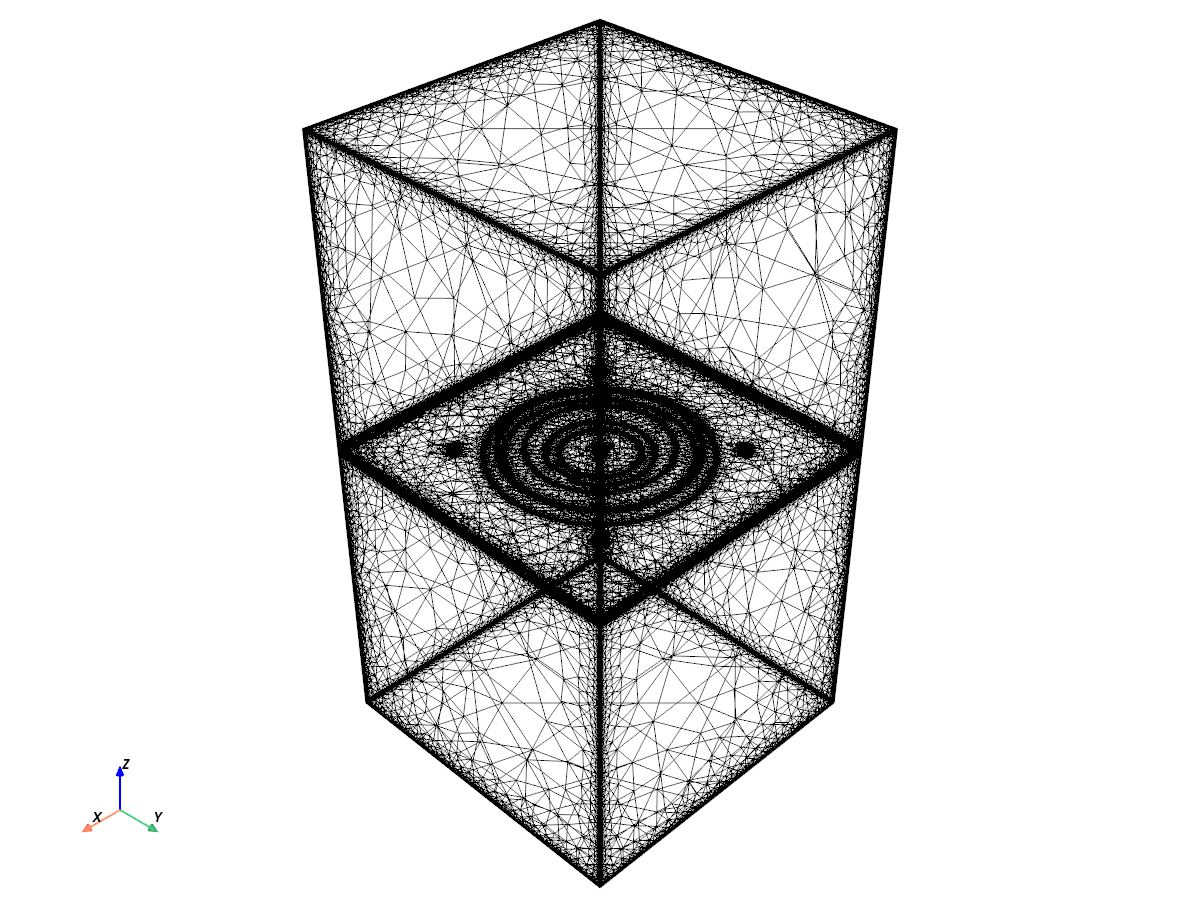

In [9]:
import gsim.viz

gsim.viz.plot_mesh(str(SIM_DIR / "palace.msh"), style="wireframe", mode="static")

**1. Volume inventory.** Every stack layer must appear as a 3-D physical
volume with the right z-extent, and the two zero-thickness metals as PEC
surfaces at their z.

In [10]:
import gmsh

gmsh.initialize()
gmsh.open(str(SIM_DIR / "palace.msh"))

for dim, tag in gmsh.model.getPhysicalGroups(3):
    name = gmsh.model.getPhysicalName(dim, tag)
    bbox = gmsh.model.getBoundingBox(
        3, gmsh.model.getEntitiesForPhysicalGroup(3, tag)[0]
    )
    logger.info(f"volume {name:>14}: z [{bbox[2]:.0f}, {bbox[5]:.0f}] µm")

for dim, tag in gmsh.model.getPhysicalGroups(2):
    name = gmsh.model.getPhysicalName(dim, tag)
    if "pec" in name:
        bbox = gmsh.model.getBoundingBox(
            2, gmsh.model.getEntitiesForPhysicalGroup(2, tag)[0]
        )
        logger.info(f"surface {name:>14}: z = {bbox[2]:.0f} µm")

Info    : Reading 'sim_palace_flipmon/palace.msh'...
Info    : 364210 nodes
Info    : 2197308 elements


2026-09-26 17:57:08.207 | INFO     | __main__:<module>:11 - volume         VACUUM: z [0, 10] µm


2026-09-26 17:57:08.208 | INFO     | __main__:<module>:11 - volume           BUMP: z [0, 10] µm


2026-09-26 17:57:08.212 | INFO     | __main__:<module>:11 - volume  SUBSTRATE_TOP: z [10, 510] µm


2026-09-26 17:57:08.219 | INFO     | __main__:<module>:11 - volume      SUBSTRATE: z [-500, 0] µm


2026-09-26 17:57:08.220 | INFO     | __main__:<module>:19 - surface         M1_pec: z = 0 µm


2026-09-26 17:57:08.220 | INFO     | __main__:<module>:19 - surface         M2_pec: z = 10 µm


Info    : Done reading 'sim_palace_flipmon/palace.msh'


**2. Element size where the fields are.** Sample the tetrahedron edge
lengths inside the inter-chip gap around the qubit and inside the bumps,
and let the size grow away from the metal.

In [11]:
node_tags, node_coords, _ = gmsh.model.mesh.getNodes()
node_lut = {int(t): i for i, t in enumerate(node_tags)}
coords = np.array(node_coords).reshape(-1, 3)
_, tet_nodes = gmsh.model.mesh.getElementsByType(4)
tet_idx = np.array([node_lut[int(n)] for n in tet_nodes]).reshape(-1, 4)
tet_pts = coords[tet_idx]
tet_centroids = tet_pts.mean(axis=1)
edges = np.stack(
    [
        tet_pts[:, 1] - tet_pts[:, 0],
        tet_pts[:, 2] - tet_pts[:, 0],
        tet_pts[:, 3] - tet_pts[:, 0],
        tet_pts[:, 2] - tet_pts[:, 1],
        tet_pts[:, 3] - tet_pts[:, 1],
        tet_pts[:, 3] - tet_pts[:, 2],
    ],
    axis=1,
)
max_edge = np.linalg.norm(edges, axis=2).max(axis=1)
radial = np.hypot(tet_centroids[:, 0], tet_centroids[:, 1])
in_gap = (tet_centroids[:, 2] >= 0) & (tet_centroids[:, 2] <= 10) & (radial < 130)
in_bulk = tet_centroids[:, 2] < -100
logger.info(
    f"gap tets near the qubit: {int(in_gap.sum())}, edge mean"
    f" {max_edge[in_gap].mean():.2f} µm, p95 {np.percentile(max_edge[in_gap], 95):.2f} µm"
)
logger.info(
    f"bulk substrate tets: edge mean {max_edge[in_bulk].mean():.1f} µm,"
    f" max {max_edge[in_bulk].max():.0f} µm"
)
assert max_edge[in_gap].mean() < 5.0, "vacuum gap under-resolved"

2026-09-26 17:57:09.169 | INFO     | __main__:<module>:23 - gap tets near the qubit: 231887, edge mean 1.54 µm, p95 5.41 µm


2026-09-26 17:57:09.171 | INFO     | __main__:<module>:27 - bulk substrate tets: edge mean 4.5 µm, max 279 µm


**3. Port connectivity.** The port surface must share mesh nodes with the
conductor group it bridges. This is the check that matters most: an earlier
port construction that overhung the lead tabs produced a mesh where the
boolean pipeline had silently deleted the tabs, leaving the port with
*zero* shared nodes against the bottom-chip metal — and every solve
afterwards returned port-local artifacts instead of the device.

In [12]:
def group_nodes(group_tag: int) -> set[int]:
    """Return all mesh node tags of a 2-D physical group."""
    nodes: set[int] = set()
    for entity in gmsh.model.getEntitiesForPhysicalGroup(2, group_tag):
        _, _, entity_nodes = gmsh.model.mesh.getElements(2, int(entity))
        for node_list in entity_nodes:
            nodes.update(int(n) for n in node_list)
    return nodes


config = json.loads((SIM_DIR / "config.json").read_text())
pec_tags = config["Boundaries"]["PEC"]["Attributes"]
# Palace's port Index is not the Gmsh physical tag: the mesh names the port
# group "P<index>". Resolve the tag by name.
port_index = config["Boundaries"]["LumpedPort"][0]["Index"]
port_tag = next(
    tag
    for dim, tag in gmsh.model.getPhysicalGroups(2)
    if gmsh.model.getPhysicalName(dim, tag) == f"P{port_index}"
)
# Identify the M1 PEC group as the one whose nodes sit at z=0 (M2 is at the
# gap height).
m1_tag = None
for tag in pec_tags:
    sample = np.array([coords[node_lut[n]] for n in list(group_nodes(tag))[:50]])
    if abs(sample[:, 2].mean()) < 1e-6:
        m1_tag = tag
        break
assert m1_tag is not None, "no PEC group at z=0"
shared = group_nodes(port_tag) & group_nodes(m1_tag)
logger.info(f"port shares {len(shared)} nodes with the bottom-chip metal")
assert shared, "port is orphaned from the metal"
gmsh.finalize()

2026-09-26 17:57:09.203 | INFO     | __main__:<module>:31 - port shares 330 nodes with the bottom-chip metal


## Eigenmode results: the qubit mode

The eigenmode search returns the qubit LC mode as mode 1, identified by three
independent checks:

- **Junction participation**: $p_J \approx 1$ — essentially all of the
  mode's magnetic energy sits in the junction inductor, the signature of a
  lumped LC resonance.
- **Inductance scaling**: doubling $L_J$ to 20 nH moves the mode by
  $1/\sqrt{L_J}$ to within a fraction of a percent (computed in the cell
  below).
- **Flip-chip topology**: severing the inter-chip galvanic connections
  (see the bump A/B below) shifts the mode by the amount the top chip's
  capacitance predicts.

This second-order solve saves the qubit mode. The inductance and bump checks
below use paired first-order solves at the same 0.4 µm mesh.

In [13]:
# Palace eigenmode output of the flip-chip flipmon (m, Re{f} (GHz), Q,
# junction EPR), embedded so the analysis runs without the cluster.
eig_m = np.array([1])
eig_f_ghz = np.array([5.044552818615])
eig_q = np.array([5.812521732084e4])
junction_epr = np.array([9.981806284965e-1])
logger.info(f"{'m':>3} {'Re{f} (GHz)':>12} {'Q':>10} {'p_J':>10}")
for m, f, q, p in zip(eig_m, eig_f_ghz, eig_q, junction_epr, strict=True):
    logger.info(f"{m:>3} {f:>12.4f} {q:>10.2e} {p:>10.2e}")

2026-09-26 17:57:09.222 | INFO     | __main__:<module>:7 -   m  Re{f} (GHz)          Q        p_J


2026-09-26 17:57:09.222 | INFO     | __main__:<module>:9 -   1       5.0446   5.81e+04   9.98e-01


Mode 1 is the qubit. Its frequency fixes the total qubit capacitance,

```{math}
C_\Sigma = \frac{1}{(2\pi f_q)^2 L_J},
```

and comparing that against the parallel-plate vacuum capacitor tells us
where the flipmon's capacitance actually lives.

In [14]:
f_q = float(eig_f_ghz[0])
c_sigma = 1 / (2 * np.pi * f_q * 1e9) ** 2 / L_J
logger.info(f"qubit mode: f_q = {f_q:.4f} GHz")
logger.info(f"implied C_sigma = {c_sigma * 1e15:.1f} fF")
logger.info(
    f"parallel-plate vacuum part: {c_vac * 1e15:.1f} fF"
    f" ({c_vac / c_sigma:.0%} of C_sigma)"
)
logger.info(
    "C_sigma is well above the parallel-plate part alone: the top silicon"
    " sits directly above the 10 um vacuum gap, so the plate fringing and"
    " the island capacitance to the surrounding ground planes on both"
    " chips all contribute."
)

2026-09-26 17:57:09.224 | INFO     | __main__:<module>:3 - qubit mode: f_q = 5.0446 GHz


2026-09-26 17:57:09.225 | INFO     | __main__:<module>:4 - implied C_sigma = 99.5 fF


2026-09-26 17:57:09.225 | INFO     | __main__:<module>:5 - parallel-plate vacuum part: 15.9 fF (16% of C_sigma)


2026-09-26 17:57:09.225 | INFO     | __main__:<module>:9 - C_sigma is well above the parallel-plate part alone: the top silicon sits directly above the 10 um vacuum gap, so the plate fringing and the island capacitance to the surrounding ground planes on both chips all contribute.


### Mesh convergence

The eigenfrequency of a lumped LC mode is set by the field capacitance the
mesh resolves, so both the element size and finite-element order matter. A
first-order sweep looked stable across six near-conductor element sizes, but
changing to second-order elements moved the mode by about 180 MHz. The
quoted qubit mode therefore uses second-order elements and `MaxIts=10`.

2026-09-26 17:57:09.228 | INFO     | __main__:<module>:12 -  h (um)    nodes  f_q (GHz)    shift


2026-09-26 17:57:09.229 | INFO     | __main__:<module>:16 -    0.75   145254     4.8401         


2026-09-26 17:57:09.229 | INFO     | __main__:<module>:16 -    0.60   178808     4.8460   +0.12%


2026-09-26 17:57:09.229 | INFO     | __main__:<module>:16 -    0.50   213635     4.8607   +0.30%


2026-09-26 17:57:09.229 | INFO     | __main__:<module>:16 -    0.40   259726     4.8609   +0.00%


...

2026-09-26 17:57:09.230 | INFO     | __main__:<module>:16 -    0.25   364308     4.8690   +0.10%


2026-09-26 17:57:09.230 | INFO     | __main__:<module>:21 - second-order elements:


2026-09-26 17:57:09.230 | INFO     | __main__:<module>:23 - 0.30 µm: 5.043264 GHz


2026-09-26 17:57:09.230 | INFO     | __main__:<module>:23 - 0.25 µm: 5.044553 GHz


findfont: Failed to find font weight bold, now using 400.


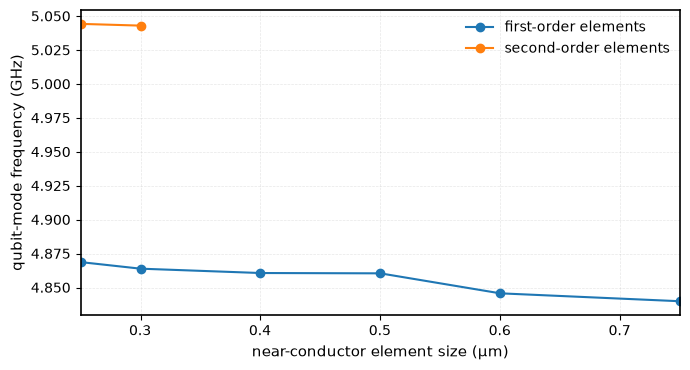

In [15]:
# Qubit-mode frequency vs near-conductor element size, first-order elements.
conv_h_um = np.array([0.75, 0.6, 0.5, 0.4, 0.3, 0.25])
conv_nodes = np.array([145254, 178808, 213635, 259726, 306826, 364308])
conv_f_ghz = np.array([
    4.840140296964,
    4.845972509737,
    4.860703757185,
    4.860935072118,
    4.864142416374,
    4.868990148822,
])
logger.info(f"{'h (um)':>7} {'nodes':>8} {'f_q (GHz)':>10} {'shift':>8}")
prev_f = None
for h, n, f in zip(conv_h_um, conv_nodes, conv_f_ghz, strict=True):
    shift = "" if prev_f is None else f"{(f / prev_f - 1) * 100:+7.2f}%"
    logger.info(f"{h:>7.2f} {n:>8} {f:>10.4f} {shift:>8}")
    prev_f = f

order2_h_um = np.array([0.30, 0.25])
order2_f_ghz = np.array([5.043264109540, 5.044552818615])
logger.info("second-order elements:")
for h, f in zip(order2_h_um, order2_f_ghz, strict=True):
    logger.info(f"{h:.2f} µm: {f:.6f} GHz")

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(conv_h_um, conv_f_ghz, "o-", label="first-order elements")
ax.plot(order2_h_um, order2_f_ghz, "o-", label="second-order elements")
ax.set_xlabel("near-conductor element size (µm)")
ax.set_ylabel("qubit-mode frequency (GHz)")
ax.legend()
fig.tight_layout()
plt.show()
plt.close(fig)

The second-order 0.30-to-0.25 µm step changes the mode by 1.29 MHz (0.026%).
The quoted mode and field use the 0.25 µm second-order solve. The
differential checks below use paired 0.4 µm first-order solves, so each
comparison keeps the same discretisation; their absolute frequencies should
not be compared with the second-order result. The remaining mesh error has
not been extrapolated to zero element size.

### Electric field of the qubit mode

The saved image samples Palace's mode 1 electric field in the inter-chip gap
at $z=5$ µm. The field around the circular capacitor and junction leads is
the spatial check on the $p_J \approx 1$ mode identification. The source
output is `output/palace/paraview/eigenmode/Cycle000001/data.pvtu` from the
0.25 µm second-order solve above. The exported field is sampled on a regular
grid and the log magnitude is smoothed over 0.8 µm for display. Palace keeps
the electric field local to each mesh element, so a 2-D cut can show mesh
seams; see its [visualization guide](https://awslabs.github.io/palace/stable/guide/postprocessing/#visualization-field-spaces-and-interface-values).
The image is embedded in the notebook output so it remains visible without
Palace or ParaView.

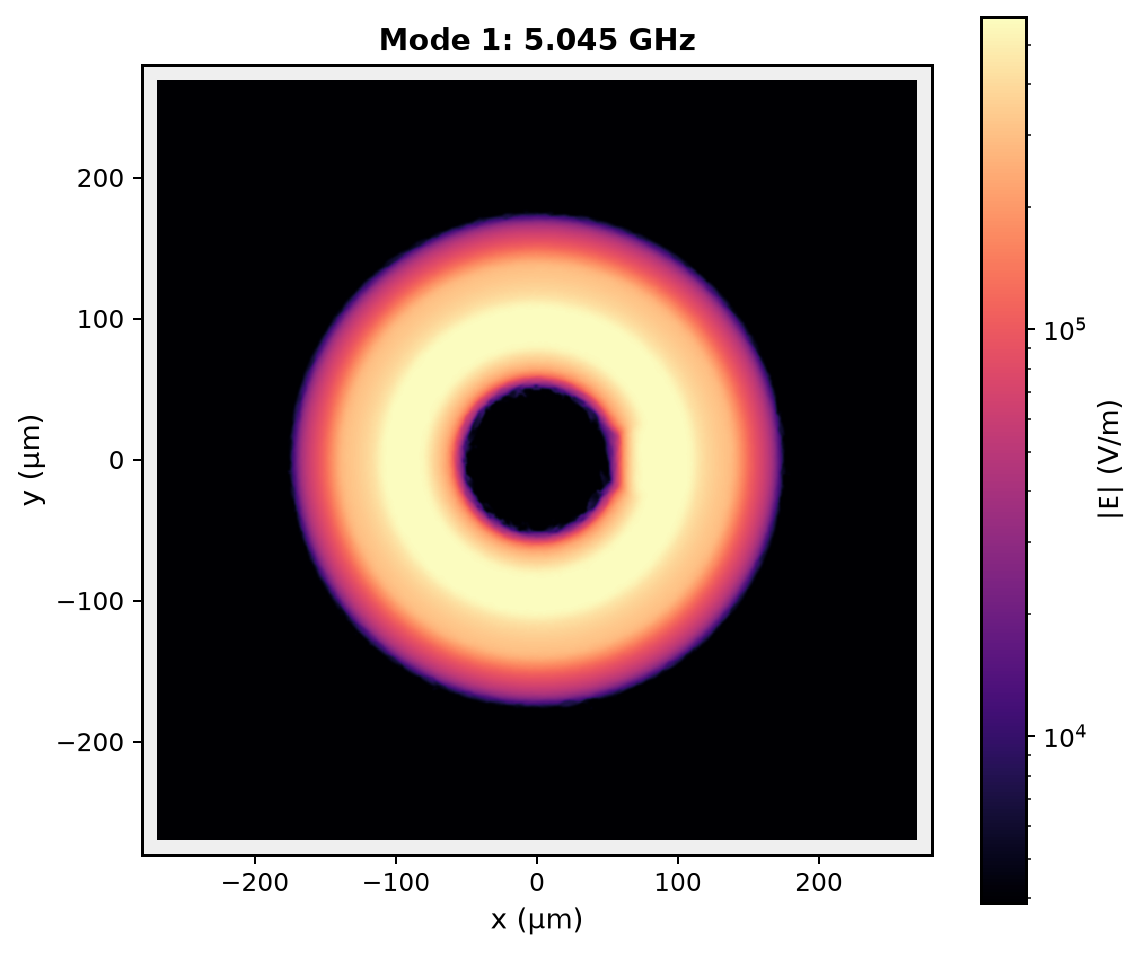

In [16]:
field_path = SIM_DIR / "output/palace/paraview/eigenmode/Cycle000001/data.pvtu"
if field_path.exists():
    import pyvista as pv

    x = np.linspace(-280, 280, 700)
    y = np.linspace(-280, 280, 700)
    grid_x, grid_y = np.meshgrid(x, y)
    points = np.column_stack((
        grid_x.ravel(),
        grid_y.ravel(),
        np.full(grid_x.size, 5.0),
    ))
    sampled = pv.PolyData(points).sample(pv.read(field_path))
    valid = np.asarray(sampled.point_data["vtkValidPointMask"], dtype=bool).reshape(
        grid_x.shape
    )
    e_real = np.asarray(sampled.point_data["E_real"], dtype=float)
    e_imag = np.asarray(sampled.point_data["E_imag"], dtype=float)
    magnitude = np.sqrt(np.sum(e_real**2 + e_imag**2, axis=1)).reshape(grid_x.shape)
    positive = magnitude[valid & (magnitude > 0)]
    vmax = float(np.percentile(positive, 99.5))
    vmin = max(vmax / 150, float(np.percentile(positive, 25)))
    sigma = 0.8 / (x[1] - x[0])
    log_field = np.log(np.where(valid, np.maximum(magnitude, vmin), vmin))
    weight = valid.astype(float)
    smooth_weight = gaussian_filter(weight, sigma)
    shown = np.where(
        valid,
        np.exp(
            gaussian_filter(log_field * weight, sigma)
            / np.maximum(smooth_weight, 1e-12)
        ),
        np.nan,
    )
    cmap = plt.get_cmap("magma").copy()
    cmap.set_bad("0.94")

    fig, ax = plt.subplots(figsize=(6.5, 5.6))
    image = ax.imshow(
        shown,
        origin="lower",
        extent=(-280, 280, -280, 280),
        cmap=cmap,
        norm=LogNorm(vmin=vmin, vmax=vmax),
        interpolation="none",
    )
    ax.set_aspect("equal")
    ax.grid(False)
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    ax.set_title(f"Mode 1: {eig_f_ghz[0]:.3f} GHz")
    fig.colorbar(image, ax=ax, label=r"$|\mathbf{E}|$ (V/m)")
    plt.show()
    plt.close(fig)
else:
    logger.info("Palace field files are needed to regenerate the embedded plot")

### Inductance scaling check

A mode's identity as the junction LC resonance can be verified directly:
re-solving with $L_J$ doubled should move it close to $1/\sqrt{2}$ and
nothing else about it.

In [17]:
# Paired first-order solves at 0.4 µm with L_J = 10 and 20 nH.
f_q_04 = 4.860935072118
p_j_04 = -9.982411520273e-1
f_q_20n = 3.438696289463
p_j_20n = -9.991112505489e-1
expected = f_q_04 / np.sqrt(2)
logger.info(f"L_J = 10 nH: f_q = {f_q_04:.4f} GHz, p_J = {p_j_04:.3f}")
logger.info(f"L_J = 20 nH: f_q = {f_q_20n:.4f} GHz, p_J = {p_j_20n:.3f}")
logger.info(f"1/sqrt(2) prediction: {expected:.4f} GHz")
logger.info(
    f"deviation: {abs(f_q_20n - expected) / expected:.2%}  (p_J unchanged,"
    " the same mode)"
)

2026-09-26 17:57:09.371 | INFO     | __main__:<module>:7 - L_J = 10 nH: f_q = 4.8609 GHz, p_J = -0.998


2026-09-26 17:57:09.372 | INFO     | __main__:<module>:8 - L_J = 20 nH: f_q = 3.4387 GHz, p_J = -0.999


2026-09-26 17:57:09.372 | INFO     | __main__:<module>:9 - 1/sqrt(2) prediction: 3.4372 GHz


2026-09-26 17:57:09.372 | INFO     | __main__:<module>:10 - deviation: 0.04%  (p_J unchanged, the same mode)


### The center bump: the flip-chip connection

The flipmon's defining feature is that the qubit island extends onto the
top chip through the center indium bump. The A/B test makes this connection
quantitative: re-solving with the bump conductivity removed demotes every
bump to a 2-D PEC patch at the bottom-chip plane, severing the *entire*
inter-chip galvanic connection — the island's tie to the top circle and
the four ground-plane ties alike — and the qubit frequency must rise.

In [18]:
# Same solve with the bump conductivity removed: every via degrades to a
# 2-D PEC patch at the bottom-chip plane, severing the island's tie to the
# top circle and the four ground-plane ties alike.
f_q_nobump = 7.038502844486
c_sigma_04 = 1 / (2 * np.pi * f_q_04 * 1e9) ** 2 / L_J
c_sigma_nobump = 1 / (2 * np.pi * f_q_nobump * 1e9) ** 2 / L_J
c_interchip = c_sigma_04 - c_sigma_nobump
logger.info(
    f"with conducting bumps:  f_q = {f_q_04:.4f} GHz, C_sigma = {c_sigma_04 * 1e15:.1f} fF"
)
logger.info(
    f"with severed connections: f_q = {f_q_nobump:.4f} GHz,"
    f" C_sigma = {c_sigma_nobump * 1e15:.1f} fF"
)
logger.info(f"inter-chip contribution: {c_interchip * 1e15:.1f} fF")
logger.info(
    f"parallel-plate vacuum estimate: {c_vac * 1e15:.1f} fF"
    f"  (fringing and the top ground plane make up the rest)"
)
assert c_interchip > c_vac, (
    "the inter-chip contribution must exceed the parallel-plate part"
)

2026-09-26 17:57:09.374 | INFO     | __main__:<module>:8 - with conducting bumps:  f_q = 4.8609 GHz, C_sigma = 107.2 fF


2026-09-26 17:57:09.374 | INFO     | __main__:<module>:11 - with severed connections: f_q = 7.0385 GHz, C_sigma = 51.1 fF


2026-09-26 17:57:09.374 | INFO     | __main__:<module>:15 - inter-chip contribution: 56.1 fF


2026-09-26 17:57:09.374 | INFO     | __main__:<module>:16 - parallel-plate vacuum estimate: 15.9 fF  (fringing and the top ground plane make up the rest)


The difference is the inter-chip connection's total effect on the qubit
capacitance: the island's vacuum-gap plate on the top chip, the top ground
plane it faces, and the ground ties all contribute, and severing them moves
the frequency by exactly their combined amount. The parallel-plate vacuum
estimate is the largest single piece of it (the cell above checks the total
exceeds it); the rest is edge fringing and the top ground plane's
proximity. This is the two-chip stack doing real electrical work in the
model.

## Summary

{func}`~qpdk.simulation.to_flip_chip_regions` and
{func}`~qpdk.simulation.flip_chip_stack` encode the same subtractive-metal
and z-stack conventions as their single-chip counterparts, so the flip-chip
workflow is the single-chip workflow with a second metal level: two
substrates, the thin vacuum gap, and conducting indium bumps.

The eigenmode solve finds the flipmon's LC mode with $p_J \approx 1$, and
the $1/\sqrt{L_J}$ scaling and the inter-chip A/B confirm it independently.
The resulting $C_\Sigma$ reflects this cell's geometry: a 10 µm gap with
silicon directly above the vacuum capacitor gives more capacitance than the
paper's ~5 µm-gap devices, whose $C_\Sigma$ sits in the 70-90 fF range
{cite:p}`liVacuumgapTransmonQubits2021`.

The mesh verification is not ceremony. The port connectivity check caught a
port whose overhang made the boolean pipeline silently delete the junction
lead tabs, orphaning the port and making every downstream solve plausibly
wrong: port-local artifact modes in an eigenmode search, an open-circuit
S₁₁ in a driven sweep. Trust a Palace result only once the inventory,
element-size and connectivity checks pass.

Natural next steps with the same setup:

- Sweep the inter-chip gap (``bump_thickness``): the field participation of
  the vacuum gap grows as the gap shrinks, the trade the flipmon paper
  quantifies {cite:p}`liVacuumgapTransmonQubits2021`.
- Add the energy-participation post-processing of
  {cite:p}`minevEnergyParticipationQuantization2021` to turn the classical
  spectrum into a full system Hamiltonian.

## References

```{bibliography}
:filter: docname in docnames
```